In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [2]:
edges_ITA= pd.read_csv("datasets/ITA_data/network/edges_list.tsv", sep="\t")
nodes_ITA= pd.read_csv("datasets/ITA_data/network/nodes_list.tsv", sep="\t")

In [6]:
rows

[[0, 234160, 'REG', 0, 'LA SPEZIA CENTRALE', 1212.0, 1214.0],
 [1, 234160, 'REG', 1, 'LA SPEZIA MIGLIARINA', 1217.0, 1219.0],
 [2, 234160, 'REG', 2, 'VEZZANO LIGURE', 1222.0, 1225.0],
 [3, 234160, 'REG', 3, 'S. STEFANO DI MAGRA', 1228.0, 1229.0],
 [4, 234160, 'REG', 4, 'AULLA LUNIGIANA', 1237.0, 1236.0],
 [5, 234160, 'REG', 5, 'VILLAFRANCA - BAGNONE', 1247.0, 1245.0],
 [6, 234160, 'REG', 6, 'PONTREMOLI', 1256.0, 1256.0],
 [7, 234160, 'REG', 7, 'BORGO VAL DI TARO', 1273.0, 1273.0],
 [8, 234160, 'REG', 8, 'BERCETO', 1289.0, 1286.0],
 [0, 103270, 'REG', 0, 'MILANO BOVISA', 582.0, 582.0],
 [1, 103270, 'REG', 1, 'SARONNO', 594.0, 594.0],
 [2, 103270, 'REG', 2, 'RESCALDINA', 600.0, 600.0],
 [3, 103270, 'REG', 3, 'CASTELLANZA', 604.0, 604.0],
 [4, 103270, 'REG', 4, 'BUSTO ARSIZIO', 606.0, 606.0],
 [5, 103270, 'REG', 5, 'FERNO LONATE POZZOLO', 612.0, 612.0],
 [6, 103270, 'REG', 6, 'MALPENSA', 617.0, 617.0],
 [0, 212730, 'MET', 0, 'NAPOLI CAMPI FLEGREI', 864.0, 865.0],
 [1, 212730, 'MET', 1, 'N

In [43]:
trains = pd.read_json("datasets/ITA_data/schedules/1-3-2015.json", lines=True)

rows = []
for _, row in trains.iterrows():
    train_id = row['identifier']
    train_type = row['type']
    path = row['path']
    if isinstance(path, list):
        for stop_num, step in enumerate(path):
            if len(step) == 3:
                station, schedule, actual = step
                rows.append([stop_num+1, train_id, train_type, station.strip(), schedule, actual])

trains_long = pd.DataFrame(rows, columns=['stop_num','train_id', 'train_type', 'station', 'schedule', 'actual'])

trains_long['delay'] = trains_long['actual'] - trains_long['schedule']
trains_long['next_station'] = trains_long.groupby('train_id')['station'].shift(-1)
trains_long['delta_delay'] = trains_long.groupby('train_id')['delay'].diff().fillna(trains_long['delay'])



In [ ]:
trains_long.head(20)

,stop_num,train_id,train_type,station,schedule,actual,delay,next_station,delta_delay
0,1,234160,REG,LA SPEZIA CENTRALE,1212.0,1214.0,2.0,LA SPEZIA MIGLIARINA,2.0
1,2,234160,REG,LA SPEZIA MIGLIARINA,1217.0,1219.0,2.0,VEZZANO LIGURE,0.0
2,3,234160,REG,VEZZANO LIGURE,1222.0,1225.0,3.0,S. STEFANO DI MAGRA,1.0
3,4,234160,REG,S. STEFANO DI MAGRA,1228.0,1229.0,1.0,AULLA LUNIGIANA,-2.0
4,5,234160,REG,AULLA LUNIGIANA,1237.0,1236.0,-1.0,VILLAFRANCA - BAGNONE,-2.0
5,6,234160,REG,VILLAFRANCA - BAGNONE,1247.0,1245.0,-2.0,PONTREMOLI,-1.0
6,7,234160,REG,PONTREMOLI,1256.0,1256.0,0.0,BORGO VAL DI TARO,2.0
7,8,234160,REG,BORGO VAL DI TARO,1273.0,1273.0,0.0,BERCETO,0.0
8,9,234160,REG,BERCETO,1289.0,1286.0,-3.0,NaN,-3.0
9,1,103270,REG,MILANO BOVISA,582.0,582.0,0.0,SARONNO,0.0


In [13]:
import numpy as np

def q_exponential(q, b):
    """
    Sample from a q-exponential distribution with parameters q and b
    """
    u = np.random.rand()
    if q == 1:
        return -b * np.log(1-u)   
    else:
        return b * ((1 - u)**(1 - q) - 1)/(1-q)


In [73]:
def departure_delay(train_id, p_dep):
    # wylosuj znak opóźnienia
    r = np.random.rand()
    if r < p_dep[0]:
        sign = 1
    elif r > p_dep[0]+p_dep[1]:
        sign = -1
    else:
        return 0  
    
    return sign * q_exponential(q_dep[kout, sign], b_dep[kout, sign])
def p_(trains_long, col_name):
    '''Probability of the delay to be positive, negative or zero'''
    if col_name == "dep_delay":
        first_stops = trains_long.loc[trains_long['stop_num'] == 1]
    else:  first_stops = trains_long.loc[trains_long['stop_num'] != 1]

    # liczba dodatnich, ujemnych i zerowych opóźnień
    num_positive = (first_stops[col_name] > 0).sum()
    num_negative = (first_stops[col_name] < 0).sum()
    num_zero     = (first_stops[col_name] == 0).sum()

    no_of_starts = len(first_stops)

    return [num_positive/no_of_starts, num_negative/no_of_starts, num_zero/no_of_starts]

In [ ]:
def exogenous_link_delay(link_length):
    r = np.random.rand()
    if r < p_exo_plus[link_length]:
        sign = 1
    elif r < p_exo_plus[link_length] + p_exo_minus[link_length]:
        sign = -1
    else:
        return 0
    return sign * q_exponential(q_exo[link_length, sign], b_exo[link_length, sign])


In [70]:
p_(trains_long, "delay")

[np.float64(0.6503969420758601), np.float64(0.0), np.float64(0.34960305792414)]

In [37]:
trains_long.loc[trains_long['stop_num'] != 1]

,stop_num,train_id,train_type,station,schedule,actual,delay
1,2,234160,REG,LA SPEZIA MIGLIARINA,1217.0,1219.0,2.0
2,3,234160,REG,VEZZANO LIGURE,1222.0,1225.0,3.0
3,4,234160,REG,S. STEFANO DI MAGRA,1228.0,1229.0,1.0
4,5,234160,REG,AULLA LUNIGIANA,1237.0,1236.0,-1.0
5,6,234160,REG,VILLAFRANCA - BAGNONE,1247.0,1245.0,-2.0
...,...,...,...,...,...,...,...
31480,11,1660,REG,ROVELLO PORRO,1071.0,1071.0,0.0
31481,12,1660,REG,SARONNO,1077.0,1077.0,0.0
31482,13,1660,REG,MILANO BOVISA,1092.0,1092.0,0.0
31483,14,1660,REG,MILANO NORD DOMODOSSOLA,1096.0,1096.0,0.0


In [55]:
def exogenous_delay(train_row, schedule_df):
    """
    train_row: bieżący przystanek train i
    schedule_df: cały DataFrame ze wszystkimi opóźnieniami
    """
    # pierwszy przystanek nie ma poprzedniego linku
    if train_row['stop_num'] == 1:
        return 0
    
    train_id = train_row['train_id']
    stop_num = train_row['stop_num']
    
    # poprzedni przystanek pociągu
    prev_stop = schedule_df[(schedule_df['train_id'] == train_id) & 
                            (schedule_df['stop_num'] == stop_num - 1)]
    
    t_start = prev_stop['actual'].values[0]
    t_end   = train_row['actual']
    station_B = train_row['station']
    
    # sprawdzamy wszystkie inne pociągi, które w tym czasie były na stacji docelowej
    neighbor_trains = schedule_df[
        (schedule_df['train_id'] != train_id) &
        (schedule_df['station'] == station_B) &
        (schedule_df['actual'] >= t_start) &
        (schedule_df['actual'] <= t_end)
    ]
    
    # jeśli ktoś był spóźniony → link nie jest czysty
    if (neighbor_trains['delta_delay'] > 0).any():
        return 0
    
    # jeśli link był czysty → exogenous = przyrost delay
    delta_delay = train_row['delta_delay']
    return delta_delay


In [56]:
trains_long['exo_delay'] = trains_long.apply(
    lambda row: exogenous_delay(row, trains_long), axis=1
)

In [57]:
trains_long[np.logical_and(trains_long['exo_delay']!=0,trains_long['stop_num']!=1)]

,stop_num,train_id,train_type,station,schedule,actual,delay,next_station,delta_delay,exo_delay
2,3,234160,REG,VEZZANO LIGURE,1222.0,1225.0,3.0,S. STEFANO DI MAGRA,1.0,1.0
3,4,234160,REG,S. STEFANO DI MAGRA,1228.0,1229.0,1.0,AULLA LUNIGIANA,-2.0,-2.0
4,5,234160,REG,AULLA LUNIGIANA,1237.0,1236.0,-1.0,VILLAFRANCA - BAGNONE,-2.0,-2.0
5,6,234160,REG,VILLAFRANCA - BAGNONE,1247.0,1245.0,-2.0,PONTREMOLI,-1.0,-1.0
6,7,234160,REG,PONTREMOLI,1256.0,1256.0,0.0,BORGO VAL DI TARO,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...
31462,2,22410,REG,VENEZIA MESTRE,952.0,952.0,0.0,PADOVA,-1.0,-1.0
31463,3,22410,REG,PADOVA,968.0,969.0,1.0,TERME EUGANEE-ABANO-MONTEGR.,1.0,1.0
31464,4,22410,REG,TERME EUGANEE-ABANO-MONTEGR.,980.0,979.0,-1.0,MONSELICE,-2.0,-2.0
31466,6,22410,REG,ROVIGO,1008.0,1004.0,-4.0,FERRARA,-2.0,-2.0


In [63]:
trains_long['dep_delay'] = np.where(trains_long['stop_num'] == 1,  trains_long['delay'], 0)       
trains_long['prop_delay']  =  trains_long['delta_delay'] - trains_long['exo_delay'] - trains_long['dep_delay']
trains_long.head()

,stop_num,train_id,train_type,station,schedule,actual,delay,next_station,delta_delay,exo_delay,dep_delay,prop_delay
0,1,234160,REG,LA SPEZIA CENTRALE,1212.0,1214.0,2.0,LA SPEZIA MIGLIARINA,2.0,0.0,2.0,0.0
1,2,234160,REG,LA SPEZIA MIGLIARINA,1217.0,1219.0,2.0,VEZZANO LIGURE,0.0,0.0,0.0,0.0
2,3,234160,REG,VEZZANO LIGURE,1222.0,1225.0,3.0,S. STEFANO DI MAGRA,1.0,1.0,0.0,0.0
3,4,234160,REG,S. STEFANO DI MAGRA,1228.0,1229.0,1.0,AULLA LUNIGIANA,-2.0,-2.0,0.0,0.0
4,5,234160,REG,AULLA LUNIGIANA,1237.0,1236.0,-1.0,VILLAFRANCA - BAGNONE,-2.0,-2.0,0.0,0.0


In [250]:
trains_long = trains_long.sort_values(['train_id', 'stop_num'])

trains_long['next_schedule'] = (
    trains_long
        .groupby('train_id')['schedule']
        .shift(-1)
)
trains_long

,stop_num,train_id,train_type,station,schedule,actual,delay,next_station,delta_delay,exo_delay,dep_delay,prop_delay,next_schedule
27673,1,120,EC,MILANO CENTRALE,505.0,505.0,0.0,MONZA,0.0,0.0,0.0,0.0,515.0
27674,2,120,EC,MONZA,515.0,515.0,0.0,COMO S. GIOVANNI,0.0,0.0,0.0,0.0,541.0
27675,3,120,EC,COMO S. GIOVANNI,541.0,548.0,7.0,CHIASSO,7.0,0.0,0.0,7.0,548.0
27676,4,120,EC,CHIASSO,548.0,556.0,8.0,NaN,1.0,1.0,0.0,0.0,NaN
30265,1,130,EC,CHIASSO,652.0,653.0,1.0,COMO S. GIOVANNI,1.0,0.0,1.0,0.0,656.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25760,7,346180,REG,PAGANI,443.0,445.0,2.0,ANGRI,0.0,0.0,0.0,0.0,447.0
25761,8,346180,REG,ANGRI,447.0,449.0,2.0,SCAFATI,0.0,0.0,0.0,0.0,453.0
25762,9,346180,REG,SCAFATI,453.0,454.0,1.0,POMPEI,-1.0,-1.0,0.0,0.0,458.0
25763,10,346180,REG,POMPEI,458.0,457.0,-1.0,TORRE ANNUNZIATA CENTRALE,-2.0,-2.0,0.0,0.0,465.0


# WYLICZENIA

## departure

In [78]:
p_(trains_long, "dep_delay")

[np.float64(0.6503969420758601), np.float64(0.0), np.float64(0.34960305792414)]

In [ ]:
data = trains_long[trains_long['dep_delay']>0].loc[:,'dep_delay']

count    2212.000000
mean        2.278481
std         3.031902
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        55.000000
Name: dep_delay, dtype: float64

In [99]:
#AI help (chatGPT) with fitting q-exponential distribution to data
import numpy as np
from scipy.optimize import minimize

data = trains_long['dep_delay'][trains_long['dep_delay']>0].values

def qexp_pdf(x, q, b):
    return (1 + b*(q-1)*x)**(1/(1-q))
def fit_q(data):

    hist, bin_edges = np.histogram(data, bins=50, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:])/2



    def fit_error(params):
        q, b = params
        if q <= 1 or b <= 0:
            return np.inf
        model = qexp_pdf(bin_centers, q, b)
        model = model / np.sum(model*(bin_centers[1]-bin_centers[0]))
        return np.mean((hist - model)**2)

    res = minimize(fit_error, [1.2, 0.01], bounds=[(1.0001,2),(1e-6,None)])
    q_fit, b_fit = res.x
    return (q_fit, b_fit)



In [100]:
data = trains_long['dep_delay'][trains_long['dep_delay']>0].values
q_fit_dep_plus, b_fit_dep_plus = fit_q(data)
print(f"Fitted parameters: q={q_fit_dep_plus:.3f}, b={b_fit_dep_plus:.5f}")

Fitted parameters: q=1.206, b=4.92359


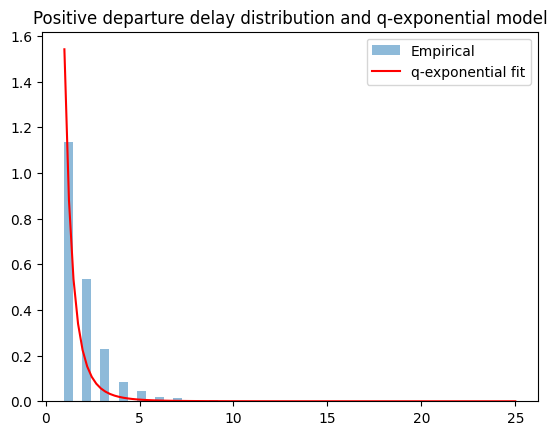

In [113]:
import matplotlib.pyplot as plt

x = np.linspace(min(data), max(data), 100)
pdf = qexp_pdf(x, q_fit_dep_plus, b_fit_dep_plus)
pdf = pdf / np.sum(pdf*(x[1]-x[0]))  #

plt.hist(data, bins=50, density=True, alpha=0.5, label='Empirical')
plt.plot(x, pdf, 'r-', label='q-exponential fit')
plt.title("Positive departure delay distribution and q-exponential model")
plt.legend()
plt.show()


## exo_delay

In [104]:
data = trains_long[trains_long['exo_delay']>0].loc[:,'exo_delay']
q_fit_exo_plus, b_fit_exo_plus = fit_q(data)
print(f"Fitted parameters: q={q_fit_exo_plus:.3f}, b={b_fit_exo_plus:.5f}")

Fitted parameters: q=1.110, b=1.54790


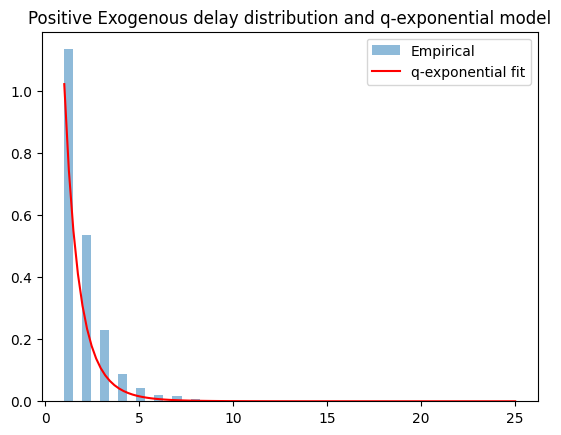

In [114]:
import matplotlib.pyplot as plt

x = np.linspace(min(data), max(data), 100)
pdf = qexp_pdf(x, q_fit_exo_plus, b_fit_exo_plus)
pdf = pdf / np.sum(pdf*(x[1]-x[0]))  # normalizacja

plt.hist(data, bins=50, density=True, alpha=0.5, label='Empirical')
plt.plot(x, pdf, 'r-', label='q-exponential fit')
plt.title("Positive Exogenous delay distribution and q-exponential model")

plt.legend()
plt.show()


In [110]:
data = trains_long[trains_long['exo_delay']<0].loc[:,'exo_delay']
data = abs(data)
q_fit_exo_minus, b_fit_exo_minus = fit_q(data)
print(f"Fitted parameters: q={q_fit_exo_minus:.3f}, b={b_fit_exo_minus:.5f}")

Fitted parameters: q=1.340, b=11826.82941


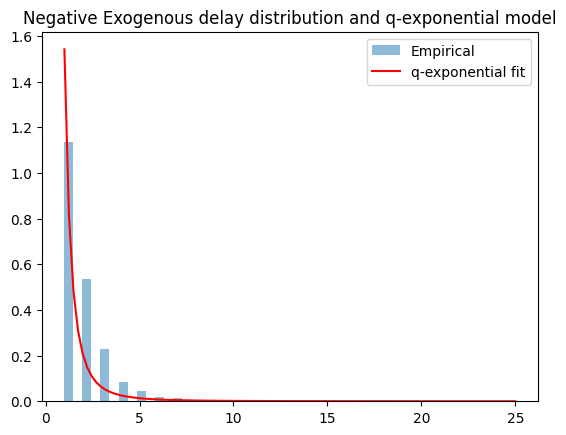

In [115]:
import matplotlib.pyplot as plt

x = np.linspace(min(data), max(data), 100)
pdf = qexp_pdf(x, q_fit_exo_minus, b_fit_exo_minus)
pdf = pdf / np.sum(pdf*(x[1]-x[0]))  # normalizacja

plt.hist(data, bins=50, density=True, alpha=0.5, label='Empirical')
plt.title("Negative Exogenous delay distribution and q-exponential model")

plt.plot(x, pdf, 'r-', label='q-exponential fit')
plt.legend()
plt.show()


## prop_delay

In [120]:
data = trains_long[trains_long['prop_delay']>0].loc[:,'prop_delay']
q_fit_prop_plus, b_fit_prop_plus = fit_q(data)
print(f"Fitted parameters: q={q_fit_prop_plus:.3f}, b={b_fit_prop_plus:.5f}")

Fitted parameters: q=1.000, b=0.57488


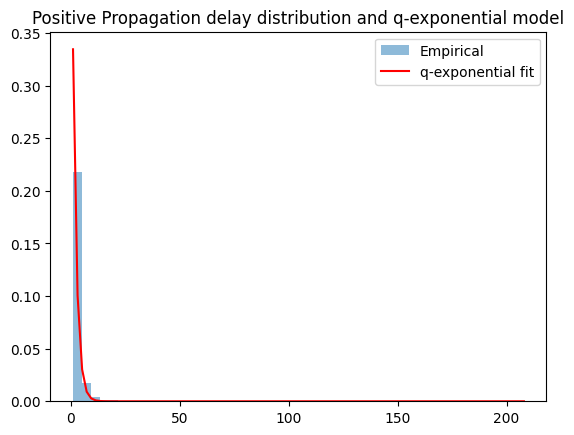

In [121]:
import matplotlib.pyplot as plt

x = np.linspace(min(data), max(data), 100)
pdf = qexp_pdf(x, q_fit_prop_plus, b_fit_prop_plus)
pdf = pdf / np.sum(pdf*(x[1]-x[0]))  # normalizacja

plt.hist(data, bins=50, density=True, alpha=0.5, label='Empirical')
plt.plot(x, pdf, 'r-', label='q-exponential fit')
plt.title("Positive Propagation delay distribution and q-exponential model")

plt.legend()
plt.show()


In [124]:
data = trains_long[trains_long['prop_delay']<0].loc[:,'prop_delay']
data = abs(data)

q_fit_prop_minus, b_fit_prop_minus = fit_q(data)
print(f"Fitted parameters: q={q_fit_prop_minus:.3f}, b={b_fit_prop_minus:.5f}")

Fitted parameters: q=1.354, b=4930.40208


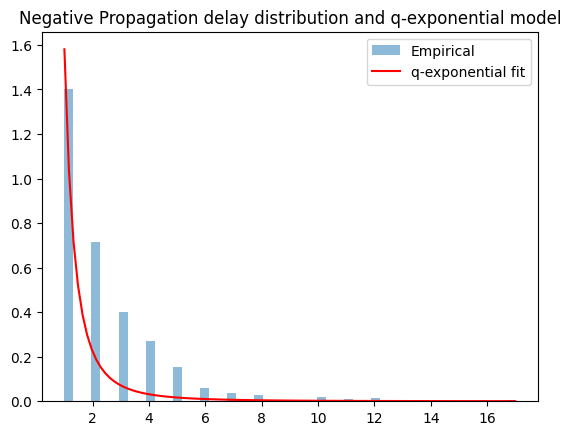

In [125]:
import matplotlib.pyplot as plt

x = np.linspace(min(data), max(data), 100)
pdf = qexp_pdf(x, q_fit_prop_minus, b_fit_prop_minus)
pdf = pdf / np.sum(pdf*(x[1]-x[0]))  # normalizacja

plt.hist(data, bins=50, density=True, alpha=0.5, label='Empirical')
plt.plot(x, pdf, 'r-', label='q-exponential fit')
plt.title("Negative Propagation delay distribution and q-exponential model")

plt.legend()
plt.show()


In [ ]:
inv_cdf = (1/b) * ( (u**(1-q) - 1) / (1-q) )

In [222]:
q = q_fit_dep_plus
b = b_fit_dep_plus
u = np.random.rand(1)
int(((1 - u)**((1 - q)/(2 - q)) - 1) / (b * (q - 1)))

C:\Users\danci\AppData\Local\Temp\ipykernel_4420\3907613560.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(((1 - u)**((1 - q)/(2 - q)) - 1) / (b * (q - 1)))


1

In [ ]:
def sample_qexp(q, b, size=1):

    u = np.random.rand(size)
    return min(1,int((1-(u)**(1-q))/(b*(1-q))))

1.2061982511102054


np.float64(4.923589633707308)

# Final Model

In [223]:
def sample_qexp(q, b, size=1):

    u = np.random.rand(size)
    x = max(1,((1 - u)**((1 - q)/(2 - q)) - 1) / (b * (q - 1)))
    return np.round(x).astype(int)

def simulate_dep_delay(q_dep, b_dep, p_pos, p_neg):
    r = np.random.rand()
    if r < p_pos:
        return sample_qexp(q_dep, b_dep)[0]
    elif r < p_pos + p_neg:
        return -sample_qexp(q_dep, b_dep)[0]
    else:
        return 0
    

#q_fit_exo_plus, b_fit_exo_plus #exo plus
#q_fit_exo_minus, b_fit_exo_minus #exo minus
#q_fit_prop_plus, b_fit_prop_plus #propagation plus
#q_fit_prop_minus, b_fit_prop_minus #propagation minus
#q_fit_dep_plus, b_fit_dep_plus # departure plus

In [ ]:
departure_plus, departure_negative, departure_zero = p_(trains_long, "dep_delay")
exo_plus,exo_negative, exo_zero = p_(trains_long, "exo_delay")

In [ ]:
df = trains_long.sort_values(['schedule']).copy()
df['sim_delay'] = 0.0
df['sim_actual'] = df['schedule']
df

,stop_num,train_id,train_type,station,schedule,actual,delay,next_station,delta_delay,exo_delay,dep_delay,prop_delay,sim_delay,sim_actual
19266,1,252890,REG,MONZA,2.0,3.0,1.0,SESTO S. GIOVANNI,1.0,0.0,1.0,0.0,0.0,2.0
21655,1,8010,REG,M N CADORNA,2.0,3.0,1.0,MILANO NORD DOMODOSSOLA,1.0,0.0,1.0,0.0,0.0,2.0
17832,1,4850,EN,BRENNERO,2.0,3.0,1.0,BRESSANONE,1.0,0.0,1.0,0.0,0.0,2.0
21656,2,8010,REG,MILANO NORD DOMODOSSOLA,5.0,5.0,0.0,MILANO BOVISA,-1.0,-1.0,0.0,0.0,0.0,5.0
19267,2,252890,REG,SESTO S. GIOVANNI,7.0,9.0,2.0,MILANO GRECO PIRELLI,1.0,1.0,0.0,0.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5852,11,203990,REG,CREMONA,1421.0,1423.0,2.0,NaN,0.0,0.0,0.0,0.0,0.0,1421.0
7299,22,23470,REG,ROMA TUSCOLANA,1421.0,1422.0,1.0,ROMA TERMINI,0.0,0.0,0.0,0.0,0.0,1421.0
24628,19,5610,IC,REGGIO CALABRIA CENTRALE,1423.0,1438.0,15.0,NaN,0.0,0.0,0.0,0.0,0.0,1423.0
27078,9,20310,REG,MILANO CENTRALE,1426.0,1431.0,5.0,NaN,0.0,0.0,0.0,0.0,0.0,1426.0


TypeError: 'generator' object is not subscriptable

In [423]:
import numpy as np
import pandas as pd

def simulate_network(trains_long,
                     q_dep_plus, b_dep_plus, q_dep_minus, b_dep_minus, p_pos_dep, p_neg_dep,
                     q_exo_plus, b_exo_plus, q_exo_minus, b_exo_minus, p_pos_exo, p_neg_exo,
                     q_prop_plus, b_prop_plus, q_prop_minus, b_prop_minus, beta=0.15):
    """
    Symulacja opóźnień w sieci pociągów zgodnie z modelem Delay Propagation.
    
    trains_long: DataFrame z kolumnami stop_num, train_id, schedule, next_station, delta_delay
    q_dep, b_dep, p_pos, p_neg: parametry q-exponential dla dep_delay
    q_exo, b_exo: parametry q-exponential dla exogenous delay
    beta: prawdopodobieństwo propagacji delay
    """
    
    # posortuj dane po czasie startu linku
    df = trains_long.sort_values(['schedule']).copy()
    df['sim_delay'] = 0.0
    df['sim_dep'] =0.0
    df['sim_exo'] =0.0
    df['sim_prop'] = 0.0
    df['sim_actual'] = df['schedule']
    df['Napoli_delay'] = 0
    i=0
    # iteracja po każdym linku
    for idx, row in df.iterrows():
        train_id = row['train_id']
        # pierwszy przystanek = dep_delay
        if row['stop_num'] == 1:
            df.at[idx, 'prev_departure_sim'] = row['schedule']
            r = np.random.rand()
            #print(f"Printing r: {r}")
            if r < p_pos_dep:
                dep = sample_qexp(q_dep_plus, b_dep_plus)
                #print(f"Printing positive! dep_sim: {dep}")
            elif r < p_pos_dep + p_neg_dep:
                dep = -sample_qexp(q_dep_minus, b_dep_minus)
            else:
                dep = 0
            #print(f"Printing dep_sim: {dep}")
            df.at[idx, 'sim_delay'] += dep
            df.at[idx, 'sim_dep'] += dep
            df.at[idx, 'sim_actual'] += dep
            row.loc['sim_delay'] += dep
            row.loc['sim_dep'] += dep
            row.loc['sim_actual'] = dep
            #print(dep)
            continue
        
        # exogenous delay na linku
        if row['stop_num'] != 1:

            prev_rows = df[(df['train_id']==train_id) & (df['stop_num']==row['stop_num']-1)]
            if prev_rows.empty:
                # brak poprzedniego stopu w danych → ustawiamy na schedule bieżącego stopu
                prev_actual = row['schedule']
                prev_delay = 0
                prev_Nap = 0
            else:
                prev_actual = prev_rows['sim_actual'].values[0]
                prev_delay = prev_rows['sim_delay'].values[0]

            df.at[idx, 'prev_departure_sim'] = prev_actual
            arrival_time = row['schedule'] + df.at[idx, 'sim_delay']
            df.at[idx, 'sim_delay'] += prev_delay
            df.at[idx, 'sim_actual'] += prev_delay

            r = np.random.rand()
            if r < p_pos_exo:
                d_exo = sample_qexp(q_exo_plus, b_exo_plus) 
            elif r < p_pos_exo + p_neg_exo:
                d_exo = -sample_qexp(q_exo_minus, b_exo_minus)
            else: d_exo = 0
            
            df.at[idx, 'sim_delay'] += d_exo
            df.at[idx, 'sim_exo'] = d_exo
            df.at[idx, 'sim_actual'] += d_exo

            d_prop = 0
            # poprzedni przystanek dla tego pociągu



            # znajdź pociągi w konfiguracji backward (czyli startują tam, gdzie kończy i)
            candidate_trains = df[
                (df['train_id'] != train_id) &
                (df['station'] == row['station'])&
                (df['stop_num'] != 1)&
                (df['sim_actual']>=prev_actual)&
                (df['sim_actual']<=df.at[idx, 'sim_actual'])
            ]


            # jeśli jest kandydat, losujemy jeden i dodajemy jego delay z prawdopodobieństwem beta
            if not candidate_trains.empty:
                jdx = candidate_trains.sample(1).index[0]
                if np.random.rand() <= beta:
                    d_prop = df.at[jdx, 'sim_delay']
            df.at[idx, 'sim_prop'] = d_prop
            df.at[idx, 'sim_delay'] += d_prop
            df.at[idx, 'sim_actual'] += d_prop
        i+=1
        if (i%1000==0):
            print(i)
    return df

In [424]:
q_fit_dep_plus
b_fit_dep_plus

np.float64(4.923589633707308)

In [425]:
results = simulate_network(trains_long,
                q_fit_dep_plus, b_fit_dep_plus, 0, 0, departure_plus, departure_negative,
                q_fit_exo_plus, b_fit_exo_plus, q_fit_exo_minus, b_fit_exo_minus, exo_plus, exo_negative,
                q_fit_prop_plus, b_fit_prop_plus, q_fit_prop_minus, b_fit_prop_minus, beta=0.15)

1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000


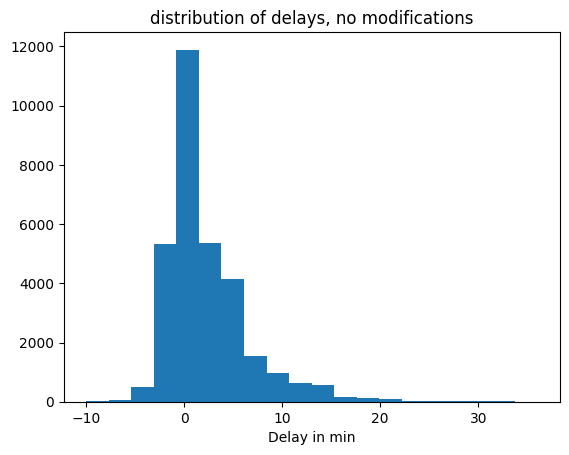

In [434]:
plt.hist(results.loc[:,"sim_delay"], bins = 20)
plt.title("distribution of delays, no modifications")
plt.xlabel("Delay in min")
plt.show()

KeyboardInterrupt: 

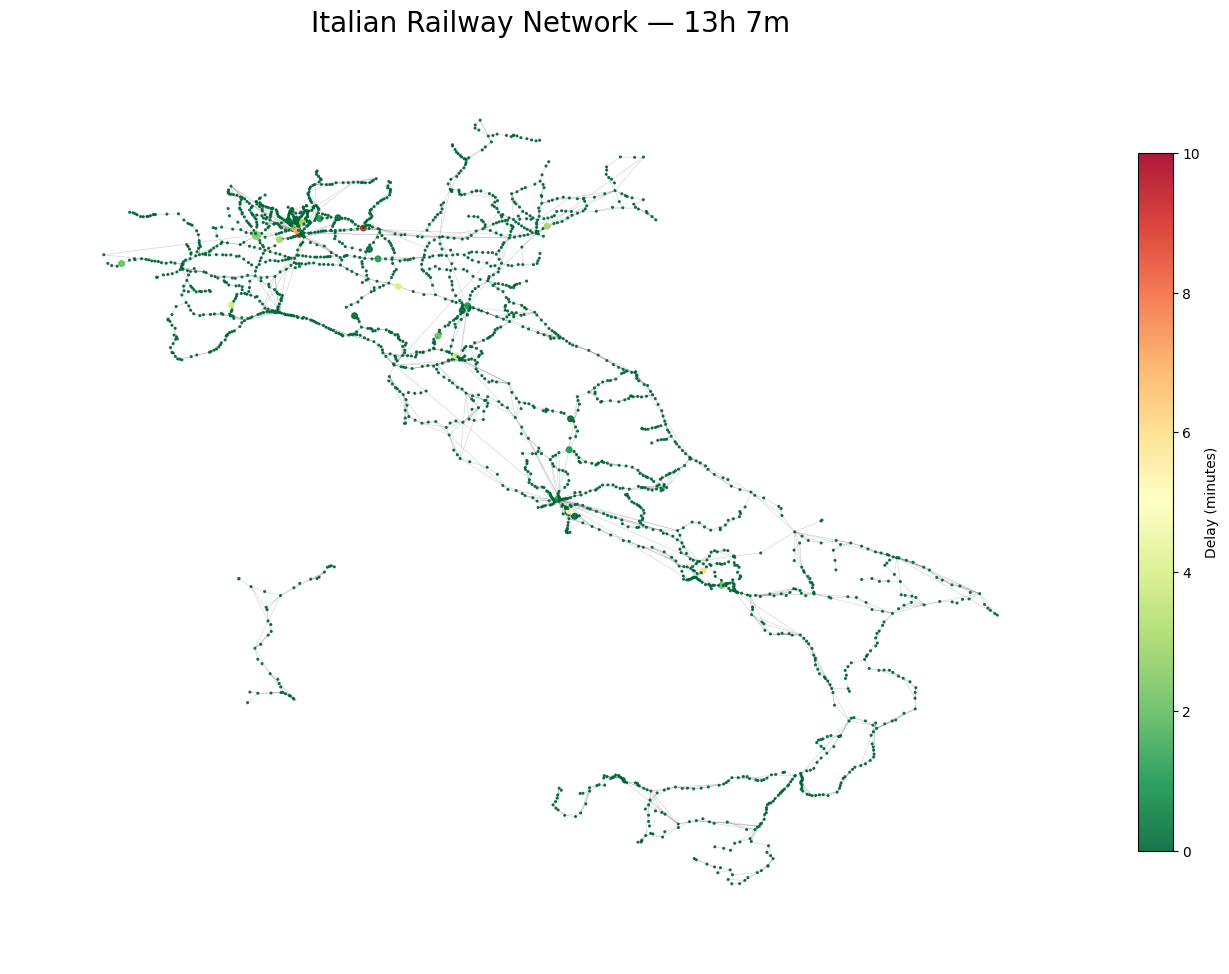

In [427]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import networkx as nx
import pandas as pd

fig, ax = plt.subplots(figsize=(15,12))

# Stacje i graf
pos = {row['n']: (row['lon'], row['lat']) for _, row in nodes_ITA.iterrows()}
G = nx.Graph()
G.add_nodes_from(nodes_ITA['n'])
G.add_edges_from(zip(edges_ITA['n1'], edges_ITA['n2']))

# Zakres czasu
time_index = pd.RangeIndex(start=int(results['sim_actual'].min()),
                           stop=int(results['sim_actual'].max()) + 1,
                           step=1)

# Grupowanie: liczba pociągów i średnie opóźnienie
grouped_count = results.groupby(['sim_actual', 'station']).size().unstack(fill_value=0).reindex(time_index, fill_value=0)
grouped_delay = results.groupby(['sim_actual', 'station'])['sim_delay'].mean().unstack(fill_value=0).reindex(time_index, fill_value=0)

# Skala kolorów: czerwony = opóźnione, zielony = na czas
cmap = plt.cm.RdYlGn_r
vmin = 0    # minimalne opóźnienie (zielony)
vmax = 10    # maksymalne opóźnienie (czerwony)

check = 0
for t in time_index:
    try:
        nodeWeights = dict(grouped_count.loc[t])
        nodeDelays = dict(grouped_delay.loc[t])
    except KeyError:
        nodeWeights = {}
        nodeDelays = {}

    node_sizes = [(nodeWeights.get(n, 0)+0.1) * 15 for n in G.nodes()]
    
    # Kolor węzłów wg opóźnienia
    node_colors = [nodeDelays.get(n, 0) for n in G.nodes()]
    
    clear_output(wait=True)
    ax.clear()
    
    nx.draw_networkx_edges(G, pos, width=0.3, alpha=0.5, edge_color='gray', ax=ax)
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=cmap,
        alpha=0.9,
        ax=ax,
        vmin=vmin,
        vmax=vmax  
    )
    if(check == 0):
        fig.colorbar(nodes, ax=ax, label='Delay (minutes)', fraction=0.03, pad=0.04)
        check = 1 

    ax.set_title(f'Italian Railway Network — {t//60}h {t%60}m', size=20)
    ax.set_axis_off()
    
    display(fig)
    #plt.pause(0.001)


In [282]:
results.to_csv('normal_simulation.csv')

In [435]:
import numpy as np
import pandas as pd

def simulate_network_delay_Napoli(trains_long,
                     q_dep_plus, b_dep_plus, q_dep_minus, b_dep_minus, p_pos_dep, p_neg_dep,
                     q_exo_plus, b_exo_plus, q_exo_minus, b_exo_minus, p_pos_exo, p_neg_exo,
                     q_prop_plus, b_prop_plus, q_prop_minus, b_prop_minus, beta=0.15):
    """
    Symulacja opóźnień w sieci pociągów zgodnie z modelem Delay Propagation.
    
    trains_long: DataFrame z kolumnami stop_num, train_id, schedule, next_station, delta_delay
    q_dep, b_dep, p_pos, p_neg: parametry q-exponential dla dep_delay
    q_exo, b_exo: parametry q-exponential dla exogenous delay
    beta: prawdopodobieństwo propagacji delay
    """
    
    # posortuj dane po czasie startu linku
    df = trains_long.sort_values(['schedule']).copy()
    df['sim_delay'] = 0.0
    df['sim_dep'] =0.0
    df['sim_exo'] =0.0
    df['sim_prop'] = 0.0
    df['sim_actual'] = df['schedule']
    df['Napoli_delay'] = 0
    i=0
    # iteracja po każdym linku
    for idx, row in df.iterrows():
        train_id = row['train_id']
        if(row['station']=='NAPOLI CENTRALE' and row['sim_actual']<911):
            
            df.at[idx, 'Napoli_delay'] = 100
            df.at[idx, 'sim_actual']+=100
            df.at[idx, 'sim_delay'] +=100
            row.loc['Napoli_delay']+=100
            row.loc['sim_actual']+=100
            row.loc['sim_delay']+=100

            print(row)

        # pierwszy przystanek = dep_delay
        if row['stop_num'] == 1:
            df.at[idx, 'prev_departure_sim'] = row['schedule']
            r = np.random.rand()
            #print(f"Printing r: {r}")
            if r < p_pos_dep:
                dep = sample_qexp(q_dep_plus, b_dep_plus)
                #print(f"Printing positive! dep_sim: {dep}")
            elif r < p_pos_dep + p_neg_dep:
                dep = -sample_qexp(q_dep_minus, b_dep_minus)
            else:
                dep = 0
            #print(f"Printing dep_sim: {dep}")
            df.at[idx, 'sim_delay'] += dep
            df.at[idx, 'sim_dep'] += dep
            df.at[idx, 'sim_actual'] += dep
            row.loc['sim_delay'] += dep
            row.loc['sim_dep'] += dep
            row.loc['sim_actual'] = dep
            #print(dep)
            continue
        
        # exogenous delay na linku
        if row['stop_num'] != 1:

            prev_rows = df[(df['train_id']==train_id) & (df['stop_num']==row['stop_num']-1)]
            if prev_rows.empty:
                # brak poprzedniego stopu w danych → ustawiamy na schedule bieżącego stopu
                prev_actual = row['schedule']
                prev_delay = 0
                prev_Nap = 0
            else:
                prev_actual = prev_rows['sim_actual'].values[0]
                prev_delay = prev_rows['sim_delay'].values[0]
                prev_Nap = prev_rows['Napoli_delay'].values[0]

            df.at[idx, 'Napoli_delay'] = prev_Nap
            df.at[idx, 'prev_departure_sim'] = prev_actual
            arrival_time = row['schedule'] + df.at[idx, 'sim_delay']
            df.at[idx, 'sim_delay'] += prev_delay
            df.at[idx, 'sim_actual'] += prev_delay

            r = np.random.rand()
            if r < p_pos_exo:
                d_exo = sample_qexp(q_exo_plus, b_exo_plus) 
            elif r < p_pos_exo + p_neg_exo:
                d_exo = -sample_qexp(q_exo_minus, b_exo_minus)
            else: d_exo = 0
            
            df.at[idx, 'sim_delay'] += d_exo
            df.at[idx, 'sim_exo'] = d_exo
            df.at[idx, 'sim_actual'] += d_exo

            d_prop = 0
            # poprzedni przystanek dla tego pociągu



            # znajdź pociągi w konfiguracji backward (czyli startują tam, gdzie kończy i)
            candidate_trains = df[
                (df['train_id'] != train_id) &
                (df['station'] == row['station'])&
                (df['stop_num'] != 1)&
                (df['sim_actual']>=prev_actual)&
                (df['sim_actual']<=df.at[idx, 'sim_actual'])
            ]


            # jeśli jest kandydat, losujemy jeden i dodajemy jego delay z prawdopodobieństwem beta
            if not candidate_trains.empty:
                jdx = candidate_trains.sample(1).index[0]
                if np.random.rand() <= beta:
                    d_prop = df.at[jdx, 'sim_delay']
            df.at[idx, 'sim_prop'] = d_prop
            df.at[idx, 'sim_delay'] += d_prop
            df.at[idx, 'sim_actual'] += d_prop
        i+=1
        if (i%1000==0):
            print(i)
    return df

In [436]:
trains_Napoli = trains_long.loc[trains_long['schedule'] > 720, :]
first_stops = trains_Napoli.groupby('train_id').first().reset_index()
subset_ids = trains_Napoli['train_id'].unique()
dummy_stops = first_stops[first_stops['train_id'].isin(subset_ids) & (first_stops['stop_num'] != 1)]
trains_subset = pd.concat([trains_Napoli, dummy_stops], ignore_index=True).sort_values(['train_id','stop_num'])
trains_subset


,stop_num,train_id,train_type,station,schedule,actual,delay,next_station,delta_delay,exo_delay,dep_delay,prop_delay,next_schedule
0,1,150,EC,CHIASSO,772.0,774.0,2.0,MONZA,2.0,0.0,2.0,0.0,801.0
1,2,150,EC,MONZA,801.0,806.0,5.0,MILANO CENTRALE,3.0,3.0,0.0,0.0,815.0
2,3,150,EC,MILANO CENTRALE,815.0,818.0,3.0,NaN,-2.0,0.0,0.0,-2.0,NaN
3,1,160,EC,MILANO CENTRALE,745.0,748.0,3.0,MONZA,3.0,0.0,3.0,0.0,755.0
4,2,160,EC,MONZA,755.0,760.0,5.0,CHIASSO,2.0,2.0,0.0,0.0,788.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20255,7,346090,REG,NOCERA SUPERIORE,1054.0,1057.0,3.0,CAVA DEI TIRRENI,6.0,6.0,0.0,0.0,1059.0
20256,8,346090,REG,CAVA DEI TIRRENI,1059.0,1063.0,4.0,VIETRI SUL MARE,1.0,1.0,0.0,0.0,1064.0
20257,9,346090,REG,VIETRI SUL MARE,1064.0,1068.0,4.0,DUOMO VIA VERNIERI,0.0,0.0,0.0,0.0,1070.0
20258,10,346090,REG,DUOMO VIA VERNIERI,1070.0,1074.0,4.0,SALERNO,0.0,0.0,0.0,0.0,1075.0


In [ ]:
results = simulate_network_delay_Napoli(trains_subset,
                q_fit_dep_plus, b_fit_dep_plus, 0, 0, departure_plus, departure_negative,
                q_fit_exo_plus, b_fit_exo_plus, q_fit_exo_minus, b_fit_exo_minus, exo_plus, exo_negative,
                q_fit_prop_plus, b_fit_prop_plus, q_fit_prop_minus, b_fit_prop_minus, beta=0.15)

stop_num                      10
train_id                    7000
train_type                    IC
station          NAPOLI CENTRALE
schedule                   735.0
actual                     733.0
delay                       -2.0
next_station              AVERSA
delta_delay                 -3.0
exo_delay                   -3.0
dep_delay                    0.0
prop_delay                   0.0
next_schedule              766.0
sim_delay                  100.0
sim_dep                      0.0
sim_exo                      0.0
sim_prop                     0.0
sim_actual                 835.0
Napoli_delay                 100
Name: 1523, dtype: object
stop_num                      10
train_id                    7000
train_type                    IC
station          NAPOLI CENTRALE
schedule                   735.0
actual                     733.0
delay                       -2.0
next_station              AVERSA
delta_delay                 -3.0
exo_delay                   -3.0
dep_delay        

In [416]:
row = results.sort_values(['Napoli_delay','train_id','sim_actual'], ascending = True). head(1)
results.sort_values(['Napoli_delay','train_id','sim_actual'], ascending = False). head(4)

,stop_num,train_id,train_type,station,schedule,actual,delay,next_station,delta_delay,exo_delay,dep_delay,prop_delay,next_schedule,sim_delay,sim_dep,sim_exo,sim_prop,sim_actual,Napoli_delay,prev_departure_sim
18888,4,243240,REG,CANCELLO,825.0,827.0,2.0,NaN,0.0,0.0,0.0,0.0,NaN,101.0,0.0,-1.0,0.0,926.0,100,919.0
18887,3,243240,REG,ACERRA,817.0,819.0,2.0,CANCELLO,1.0,1.0,0.0,0.0,825.0,102.0,0.0,-1.0,0.0,919.0,100,916.0
18886,2,243240,REG,CASALNUOVO,813.0,814.0,1.0,ACERRA,-1.0,-1.0,0.0,0.0,817.0,103.0,0.0,2.0,0.0,916.0,100,901.0
18885,1,243240,REG,NAPOLI CENTRALE,800.0,802.0,2.0,CASALNUOVO,2.0,0.0,2.0,0.0,813.0,101.0,1.0,0.0,0.0,901.0,100,800.0


In [419]:
results.sort_values(['sim_delay','train_id','sim_actual'], ascending = False). head(4)

,stop_num,train_id,train_type,station,schedule,actual,delay,next_station,delta_delay,exo_delay,dep_delay,prop_delay,next_schedule,sim_delay,sim_dep,sim_exo,sim_prop,sim_actual,Napoli_delay,prev_departure_sim
884,5,3840,REG,M N CADORNA,1322.0,1322.0,0.0,NaN,1.0,0.0,0.0,1.0,NaN,661.0,0.0,0.0,0.0,1983.0,0,1977.0
883,4,3840,REG,MILANO BOVISA,1316.0,1315.0,-1.0,M N CADORNA,-1.0,-1.0,0.0,0.0,1322.0,661.0,0.0,-1.0,380.0,1977.0,0,1585.0
1515,12,6810,REG,INVERIGO,1256.0,1258.0,2.0,LAMBRUGO - LURAGO,0.0,0.0,0.0,0.0,1263.0,645.0,0.0,3.0,0.0,1901.0,0,1894.0
1511,8,6810,REG,CABIATE,1242.0,1245.0,3.0,MARIANO COMENSE,1.0,1.0,0.0,0.0,1244.0,645.0,0.0,1.0,0.0,1887.0,0,1883.0


In [422]:
results.loc[results['train_id']==6810]

,stop_num,train_id,train_type,station,schedule,actual,delay,next_station,delta_delay,exo_delay,dep_delay,prop_delay,next_schedule,sim_delay,sim_dep,sim_exo,sim_prop,sim_actual,Napoli_delay,prev_departure_sim
1504,1,6810,REG,M N CADORNA,1208.0,1208.0,0.0,MILANO NORD DOMODOSSOLA,0.0,0.0,0.0,0.0,1211.0,0.0,0.0,0.0,0.0,1208.0,0,1208.0
1505,2,6810,REG,MILANO NORD DOMODOSSOLA,1211.0,1211.0,0.0,MILANO BOVISA,0.0,0.0,0.0,0.0,1215.0,94.0,0.0,0.0,94.0,1305.0,0,1208.0
1506,3,6810,REG,MILANO BOVISA,1215.0,1215.0,0.0,M.N. AFFORI,0.0,0.0,0.0,0.0,1218.0,295.0,0.0,0.0,201.0,1510.0,0,1305.0
1507,4,6810,REG,M.N. AFFORI,1218.0,1218.0,0.0,CESANO MADERNO,0.0,0.0,0.0,0.0,1231.0,294.0,0.0,-1.0,0.0,1512.0,0,1510.0
1508,5,6810,REG,CESANO MADERNO,1231.0,1233.0,2.0,SEVESO,2.0,2.0,0.0,0.0,1235.0,642.0,0.0,0.0,348.0,1873.0,0,1512.0
1509,6,6810,REG,SEVESO,1235.0,1236.0,1.0,MEDA,-1.0,-1.0,0.0,0.0,1239.0,642.0,0.0,0.0,0.0,1877.0,0,1873.0
1510,7,6810,REG,MEDA,1239.0,1241.0,2.0,CABIATE,1.0,1.0,0.0,0.0,1242.0,644.0,0.0,2.0,0.0,1883.0,0,1877.0
1511,8,6810,REG,CABIATE,1242.0,1245.0,3.0,MARIANO COMENSE,1.0,1.0,0.0,0.0,1244.0,645.0,0.0,1.0,0.0,1887.0,0,1883.0
1512,9,6810,REG,MARIANO COMENSE,1244.0,1247.0,3.0,CARUGO - GIUSSANO,0.0,0.0,0.0,0.0,1249.0,644.0,0.0,-1.0,0.0,1888.0,0,1887.0
1513,10,6810,REG,CARUGO - GIUSSANO,1249.0,1251.0,2.0,AROSIO,-1.0,-1.0,0.0,0.0,1252.0,643.0,0.0,-1.0,0.0,1892.0,0,1888.0


In [339]:
pos = {row['n']: (row['lon'], row['lat']) for _, row in nodes_ITA.iterrows()}
G = nx.Graph()
G.add_nodes_from(nodes_ITA['n'])
G.add_edges_from(zip(edges_ITA['n1'], edges_ITA['n2']))

window = 8  # ±8 minut
weights = np.linspace(0, 1, 2*window + 1)  # długość okna = 16 minut
stations = G.nodes()
time_index = pd.RangeIndex(start=int(results['sim_actual'].min()),
                           stop=int(results['sim_actual'].max()) + 1,
                           step=1)

# Tworzymy tablice: wiersze = czas, kolumny = stacje
weights_matrix = np.zeros((len(time_index), len(stations)))
delays_matrix  = np.zeros((len(time_index), len(stations)))

# Wypełnij wartości z danych
for i, t in enumerate(time_index):
    nodeWeights = grouped_count.loc[t] if t in grouped_count.index else pd.Series(0, index=stations)
    nodeDelays  = grouped_delay.loc[t] if t in grouped_delay.index else pd.Series(0, index=stations)
    weights_matrix[i, :] = [nodeWeights.get(s, 0) for s in stations]
    delays_matrix[i, :]  = [nodeDelays.get(s, 0) for s in stations]
weights_interp = np.zeros_like(weights_matrix)
delays_interp  = np.zeros_like(delays_matrix)

for i in range(len(time_index)):
    start_idx = max(0, i - window)
    end_idx   = min(len(time_index)-1, i + window)
    window_slice = slice(start_idx, end_idx+1)
    # linowe wagi w oknie (równomierne)
    w = np.linspace(0, 1, end_idx - start_idx + 1)
    w /= w.sum()  # normalizacja

    weights_interp[i, :] = np.dot(w, weights_matrix[window_slice, :])
    delays_interp[i, :]  = np.dot(w, delays_matrix[window_slice, :])


KeyboardInterrupt: 

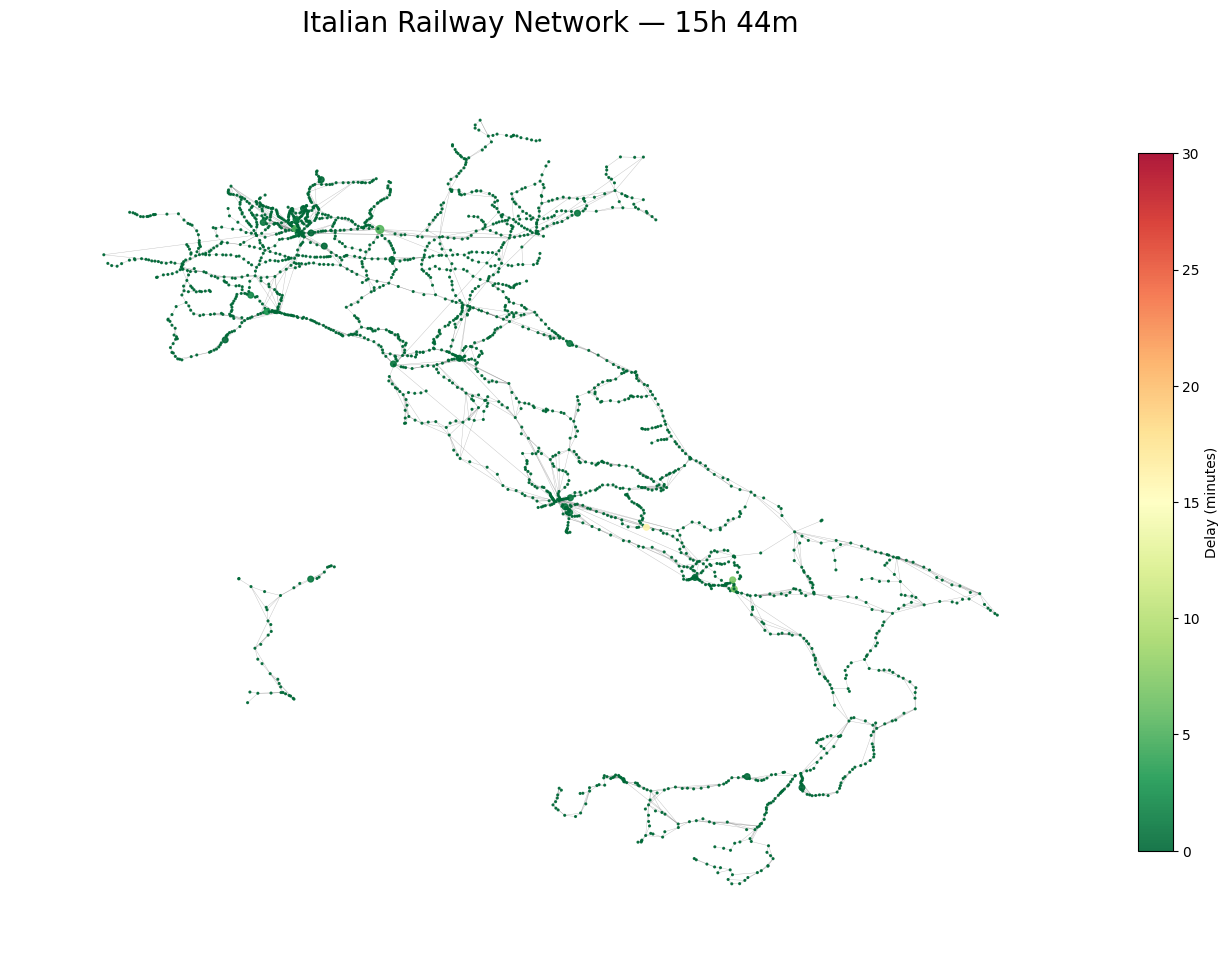

In [ ]:

fig, ax = plt.subplots(figsize=(15,12))

# Stacje i graf
pos = {row['n']: (row['lon'], row['lat']) for _, row in nodes_ITA.iterrows()}
G = nx.Graph()
G.add_nodes_from(nodes_ITA['n'])
G.add_edges_from(zip(edges_ITA['n1'], edges_ITA['n2']))

# Zakres czasu
time_index = pd.RangeIndex(start=int(results['sim_actual'].min()),
                           stop=int(results['sim_actual'].max()) + 1,
                           step=1)

# Grupowanie: liczba pociągów i średnie opóźnienie
grouped_count = results.groupby(['sim_actual', 'station']).size().unstack(fill_value=0).reindex(time_index, fill_value=0)
grouped_delay = results.groupby(['sim_actual', 'station'])['sim_delay'].mean().unstack(fill_value=0).reindex(time_index, fill_value=0)

# Skala kolorów: czerwony = opóźnione, zielony = na czas
cmap = plt.cm.RdYlGn_r
vmin = 0    # minimalne opóźnienie (zielony)
vmax = 30    # maksymalne opóźnienie (czerwony)

check = 0
for t in time_index:
    try:
        nodeWeights = dict(grouped_count.loc[t])
        nodeDelays = dict(grouped_delay.loc[t])
    except KeyError:
        nodeWeights = {}
        nodeDelays = {}

    node_sizes = [(nodeWeights.get(n, 0)+0.1) * 15 for n in G.nodes()]
    
    # Kolor węzłów wg opóźnienia
    node_colors = [nodeDelays.get(n, 0) for n in G.nodes()]
    
    clear_output(wait=True)
    ax.clear()
    
    nx.draw_networkx_edges(G, pos, width=0.3, alpha=0.5, edge_color='gray', ax=ax)
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=cmap,
        alpha=0.9,
        ax=ax,
        vmin=vmin,
        vmax=vmax  
    )
    if(check == 0):
        fig.colorbar(nodes, ax=ax, label='Delay (minutes)', fraction=0.03, pad=0.04)
        check = 1 

    ax.set_title(f'Italian Railway Network — {t//60}h {t%60}m', size=20)
    ax.set_axis_off()
    
    display(fig)
    #plt.pause(0.001)


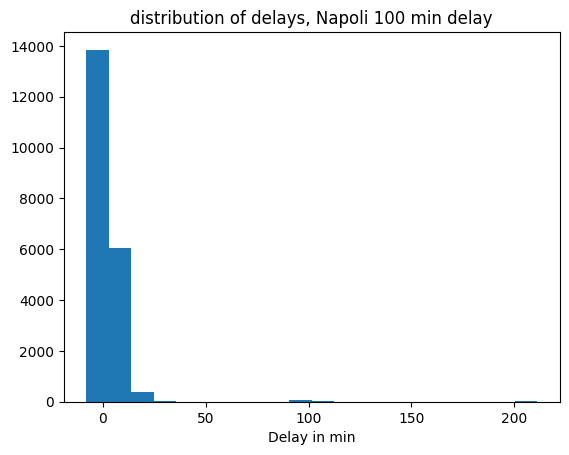

In [439]:
plt.hist(results.loc[:,"sim_delay"], bins = 20)
plt.title("distribution of delays, Napoli 100 min delay")
plt.xlabel("Delay in min")
plt.show()

In [440]:
results = simulate_network_delay_Napoli(trains_subset,
                q_fit_dep_plus, b_fit_dep_plus, 0, 0, departure_plus, departure_negative,
                q_fit_exo_plus, b_fit_exo_plus, q_fit_exo_minus, b_fit_exo_minus, exo_plus, exo_negative,
                q_fit_prop_plus, b_fit_prop_plus, q_fit_prop_minus, b_fit_prop_minus, beta=1)

stop_num                      10
train_id                    7000
train_type                    IC
station          NAPOLI CENTRALE
schedule                   735.0
actual                     733.0
delay                       -2.0
next_station              AVERSA
delta_delay                 -3.0
exo_delay                   -3.0
dep_delay                    0.0
prop_delay                   0.0
next_schedule              766.0
sim_delay                  100.0
sim_dep                      0.0
sim_exo                      0.0
sim_prop                     0.0
sim_actual                 835.0
Napoli_delay                 100
Name: 1523, dtype: object
stop_num                      10
train_id                    7000
train_type                    IC
station          NAPOLI CENTRALE
schedule                   735.0
actual                     733.0
delay                       -2.0
next_station              AVERSA
delta_delay                 -3.0
exo_delay                   -3.0
dep_delay        

KeyboardInterrupt: 

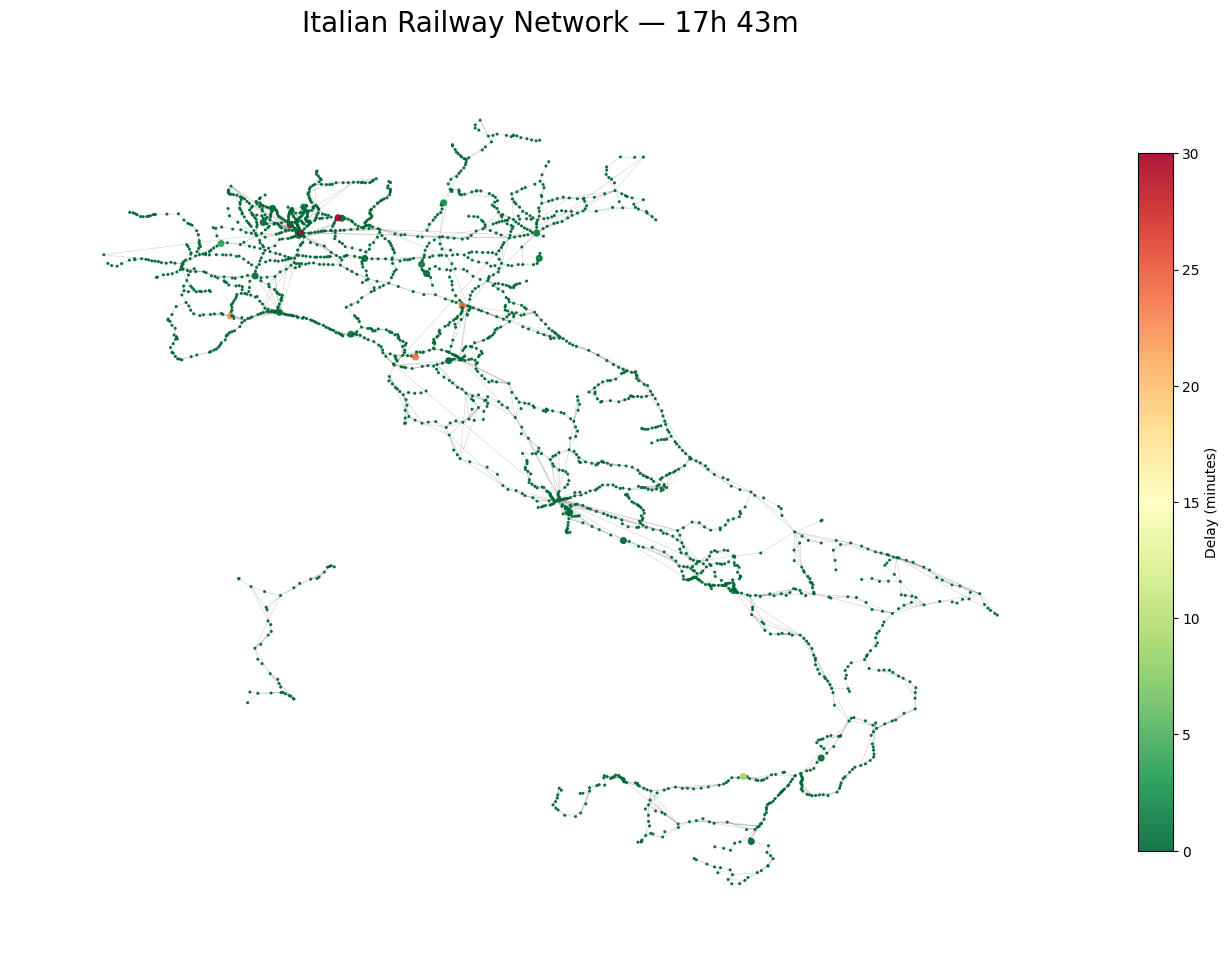

In [441]:

fig, ax = plt.subplots(figsize=(15,12))

# Stacje i graf
pos = {row['n']: (row['lon'], row['lat']) for _, row in nodes_ITA.iterrows()}
G = nx.Graph()
G.add_nodes_from(nodes_ITA['n'])
G.add_edges_from(zip(edges_ITA['n1'], edges_ITA['n2']))

# Zakres czasu
time_index = pd.RangeIndex(start=int(results['sim_actual'].min()),
                           stop=int(results['sim_actual'].max()) + 1,
                           step=1)

# Grupowanie: liczba pociągów i średnie opóźnienie
grouped_count = results.groupby(['sim_actual', 'station']).size().unstack(fill_value=0).reindex(time_index, fill_value=0)
grouped_delay = results.groupby(['sim_actual', 'station'])['sim_delay'].mean().unstack(fill_value=0).reindex(time_index, fill_value=0)

# Skala kolorów: czerwony = opóźnione, zielony = na czas
cmap = plt.cm.RdYlGn_r
vmin = 0    # minimalne opóźnienie (zielony)
vmax = 30    # maksymalne opóźnienie (czerwony)

check = 0
for t in time_index:
    try:
        nodeWeights = dict(grouped_count.loc[t])
        nodeDelays = dict(grouped_delay.loc[t])
    except KeyError:
        nodeWeights = {}
        nodeDelays = {}

    node_sizes = [(nodeWeights.get(n, 0)+0.1) * 15 for n in G.nodes()]
    
    # Kolor węzłów wg opóźnienia
    node_colors = [nodeDelays.get(n, 0) for n in G.nodes()]
    
    clear_output(wait=True)
    ax.clear()
    
    nx.draw_networkx_edges(G, pos, width=0.3, alpha=0.5, edge_color='gray', ax=ax)
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=cmap,
        alpha=0.9,
        ax=ax,
        vmin=vmin,
        vmax=vmax  
    )
    if(check == 0):
        fig.colorbar(nodes, ax=ax, label='Delay (minutes)', fraction=0.03, pad=0.04)
        check = 1 

    ax.set_title(f'Italian Railway Network — {t//60}h {t%60}m', size=20)
    ax.set_axis_off()
    
    display(fig)
    #plt.pause(0.001)


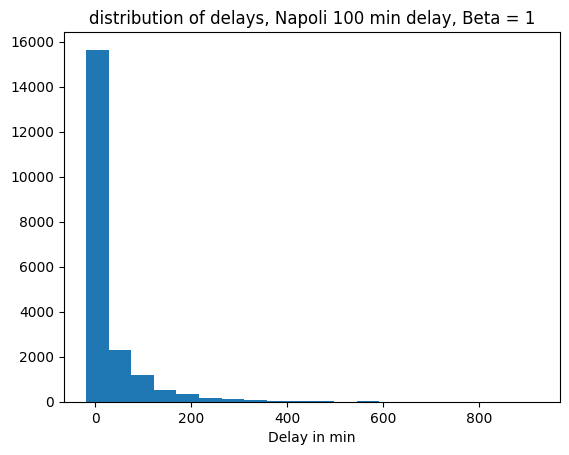

In [443]:
plt.hist(results.loc[:,"sim_delay"], bins = 20)
plt.title("distribution of delays, Napoli 100 min delay, Beta = 1")
plt.xlabel("Delay in min")
plt.show()